In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
train_path = "/content/drive/MyDrive/mini_project/split_dataset/train"
val_path   = "/content/drive/MyDrive/mini_project/split_dataset/val"
test_path  = "/content/drive/MyDrive/mini_project/split_dataset/test"

ADD AUGMENTATION

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

LOAD

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

LOAD XCEPTION MODEL

In [6]:
base_model = tf.keras.applications.Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


ADD CUSTOM LAYERS

In [7]:
base_model = tf.keras.applications.Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

COMPILE

In [11]:
x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(3, activation='softmax')(x)

model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
train_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/mini_project/split_dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/mini_project/split_dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 10606 images belonging to 3 classes.
Found 2273 images belonging to 3 classes.


TRAIN MODEL

In [17]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
332/332 ━━━━━━━━━━━━━━━━━━━━ 5436s 16s/step - accuracy: 0.8408 - loss: 0.3934 - val_accuracy: 0.8583 - val_loss: 0.3819
Epoch 2/5
332/332 ━━━━━━━━━━━━━━━━━━━━ 217s 653ms/step - accuracy: 0.8754 - loss: 0.3185 - val_accuracy: 0.8883 - val_loss: 0.2942
Epoch 3/5
332/332 ━━━━━━━━━━━━━━━━━━━━ 215s 646ms/step - accuracy: 0.8858 - loss: 0.2958 - val_accuracy: 0.8883 - val_loss: 0.2800
Epoch 4/5
332/332 ━━━━━━━━━━━━━━━━━━━━ 212s 637ms/step - accuracy: 0.8916 - loss: 0.2764 - val_accuracy: 0.8993 - val_loss: 0.2554
Epoch 5/5
332/332 ━━━━━━━━━━━━━━━━━━━━ 211s 636ms/step - accuracy: 0.8922 - loss: 0.2762 - val_accuracy: 0.9045 - val_loss: 0.2617


SAVE MODEL

In [18]:
model.save('/content/drive/MyDrive/mini_project/xception_final.keras')

Model loaded successfully ✅
Found 2275 images belonging to 3 classes.
72/72 ━━━━━━━━━━━━━━━━━━━━ 717s 10s/step

Actual vs Predicted Table:

      Actual Predicted
0   covid-19    normal
1   covid-19  covid-19
2   covid-19  covid-19
3   covid-19  covid-19
4   covid-19  covid-19
5   covid-19    normal
6   covid-19  covid-19
7   covid-19    normal
8   covid-19    normal
9   covid-19  covid-19
10  covid-19  covid-19
11  covid-19  covid-19
12  covid-19  covid-19
13  covid-19  covid-19
14  covid-19  covid-19
15  covid-19  covid-19
16  covid-19  covid-19
17  covid-19  covid-19
18  covid-19  covid-19
19  covid-19    normal

Test Accuracy: 0.9002197802197802

Confusion Matrix:

[[ 375  164    4]
 [  27 1488   14]
 [   1   17  185]]


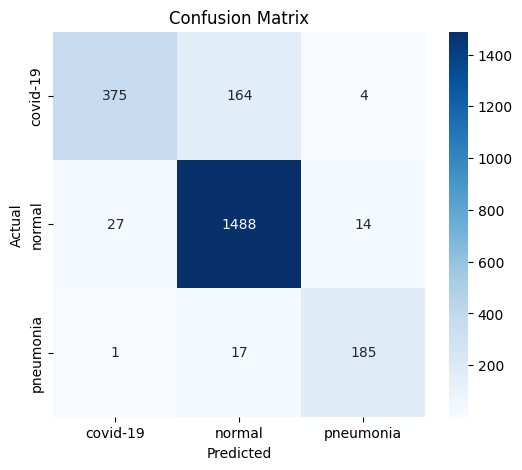


Classification Report:

              precision    recall  f1-score   support

    covid-19       0.93      0.69      0.79       543
      normal       0.89      0.97      0.93      1529
   pneumonia       0.91      0.91      0.91       203

    accuracy                           0.90      2275
   macro avg       0.91      0.86      0.88      2275
weighted avg       0.90      0.90      0.90      2275



In [20]:
# -------- PATHS --------
test_path = "/content/drive/MyDrive/mini_project/split_dataset/test"
model_path = "/content/drive/MyDrive/mini_project/xception_final.keras"

# -------- LOAD MODEL --------
model = load_model(model_path)
print("Model loaded successfully ✅")

# -------- LOAD TEST DATA --------
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# -------- PREDICTIONS --------
predictions = model.predict(test_data, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

# -------- TRUE LABELS --------
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# -------- ACTUAL vs PREDICTED TABLE --------
results = pd.DataFrame({
    "Actual": [class_labels[i] for i in true_classes],
    "Predicted": [class_labels[i] for i in predicted_classes]
})

print("\nActual vs Predicted Table:\n")
print(results.head(20))   # show first 20 rows

# -------- ACCURACY --------
accuracy = accuracy_score(true_classes, predicted_classes)
print("\nTest Accuracy:", accuracy)

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(true_classes, predicted_classes)

print("\nConfusion Matrix:\n")
print(cm)

# -------- PLOT --------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -------- CLASSIFICATION REPORT --------
print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

In [5]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np
import cv2

model = load_model("xception.keras")

img_path = "black_photo_cat.jpeg"

# -------- Load Image --------
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224,224))

# -------- Check if image is grayscale-like --------
gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Calculate color variation
color_diff = np.mean(np.abs(img_resized[:,:,0] - img_resized[:,:,1]))

# Threshold (tune if needed)
if color_diff > 15:
    print("⚠️ Irrelevant Input (Not a Chest X-ray Image)")
else:
    # -------- Normal Prediction --------
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    class_names = ["covid-19", "normal", "pneumonia"]

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    print("Predicted Disease:", predicted_class)
    print("Confidence:", confidence)

⚠️ Irrelevant Input (Not a Chest X-ray Image)
